# Figure 3 (all models): zero-shot L2 and cosine

Bar plot for **all non-random CochCNN9** models (including **byol-a**), plus **Whisper** and **AudioMAE** last-layer points.

- Row 1: squared L2 judgement (`sqr_l2_judgement`)
- Row 2: cosine judgement (`cos_judgement`)
- Columns: Loudness / Melody / Mandarin (same tasks as `figure_3_zero_shot_with_whisper.ipynb`)


In [59]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, str(Path("..").resolve()))

import figure_utils
from importlib import reload
reload(figure_utils)
from figure_utils import (
    normalize_model_name,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
    set_bar_labels,
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

%matplotlib inline

fig_out_dir = Path("CCN_2026_figs")
fig_out_dir.mkdir(parents=True, exist_ok=True)


## Load CochCNN9 zero-shot CSVs


In [2]:

RESULTS_DIR = Path("/mnt/home/igriffith/ceph/projects/cochdnn/results_dfs")
DEFAULT_LAYER = "relu4"


def _layer_from_filename(path):
    stem = path.stem
    if "_results_" in stem:
        suffix = stem.split("_results_", 1)[-1]
        return suffix if suffix else DEFAULT_LAYER
    return DEFAULT_LAYER


def _load_task_csvs(glob_pattern):
    paths = sorted(RESULTS_DIR.glob(glob_pattern))
    if not paths:
        return pd.DataFrame()
    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["layer"] = _layer_from_filename(p)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


speech_loudness_df = _load_task_csvs("zero_shot_speech_commands_level_discrimination_results*v2.csv")
model_name_map = {
    model: model_name
    for model, model_name in speech_loudness_df[["model", "model_name"]].dropna().drop_duplicates().values
}
speech_loudness_df["model_name"] = speech_loudness_df["model"].map(model_name_map)
speech_loudness_df["task"] = "Loudness order discrimination"
speech_loudness_df.layer = speech_loudness_df.layer.str.replace("_v2", "")

melody_df = _load_task_csvs("zero_shot_nsynth_melody_match_results*v2.csv")
melody_df["task"] = "Melody match"
melody_df.layer = melody_df.layer.str.replace("_v2", "")

mandarin_df = _load_task_csvs("zero_shot_mandarin_tone_results*v2.csv")
mandarin_df["task"] = "Mandarin tone discrimination"
mandarin_df.layer = mandarin_df.layer.str.replace("_v2", "")

results_df = pd.concat([speech_loudness_df, melody_df, mandarin_df], ignore_index=True)
results_df.model_name = results_df.model_name.str.replace("DNN", "CNN")

print(f"Speech: {len(speech_loudness_df)}, NSynth: {len(melody_df)}, Mandarin: {len(mandarin_df)}")
print(f"Unique models: {sorted(results_df.model_name.dropna().unique().tolist())}")


Speech: 28000, NSynth: 67200, Mandarin: 27986
Unique models: ['CochCNN9 random weights', 'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5', 'CochCNN9 scaled supervised', 'CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5', 'CochCNN9 supervised audioset', 'CochCNN9 supervised multi-task', 'CochCNN9 supervised word', 'byol-a']


## Load Whisper and AudioMAE layerwise CSVs


In [3]:

whisper_mandarin = pd.read_csv(RESULTS_DIR / "zero_shot_mandarin_whisper_layerwise.csv")
whisper_mandarin["task"] = "Mandarin tone discrimination"

whisper_nsynth = pd.read_csv(RESULTS_DIR / "zero_shot_nsynth_whisper_layerwise.csv")
whisper_nsynth["task"] = "Melody match"

whisper_speech = pd.read_csv(RESULTS_DIR / "zero_shot_speech_commands_whisper_layerwise.csv")
whisper_speech["task"] = "Loudness order discrimination"

whisper_all = pd.concat([whisper_mandarin, whisper_nsynth, whisper_speech], ignore_index=True)
print(f"Whisper rows: {len(whisper_all)}")


Whisper rows: 554337


In [4]:

audiomae_mandarin_path = RESULTS_DIR / "zero_shot_mandarin_audiomae_layerwise.csv"
audiomae_nsynth_path = RESULTS_DIR / "zero_shot_nsynth_audiomae_layerwise.csv"
audiomae_speech_path = RESULTS_DIR / "zero_shot_speech_commands_audiomae_layerwise.csv"

audiomae_dfs = []
for path, task in [
    (audiomae_mandarin_path, "Mandarin tone discrimination"),
    (audiomae_nsynth_path, "Melody match"),
    (audiomae_speech_path, "Loudness order discrimination"),
]:
    if path.exists():
        df = pd.read_csv(path)
        df["task"] = task
        audiomae_dfs.append(df)

if audiomae_dfs:
    audiomae_all = pd.concat(audiomae_dfs, ignore_index=True)
    print(f"AudioMAE rows: {len(audiomae_all)}")
else:
    audiomae_all = pd.DataFrame()
    print("No AudioMAE CSVs found.")


AudioMAE rows: 114387


## Plot: all CochCNN9 (no random) + byol-a + Whisper + AudioMAE


Coch/BYOL models in plot (13): ['CochCNN9 supervised multi-task', 'CochCNN9 supervised word', 'CochCNN9 supervised audioset', 'CochCNN9 scaled supervised', 'CochCNN9 ssl λ=0.0', 'CochCNN9 ssl λ=0.1', 'CochCNN9 ssl λ=0.2', 'CochCNN9 ssl λ=0.3', 'CochCNN9 ssl λ=0.4', 'CochCNN9 ssl λ=0.5', 'CochCNN9 scaled ssl λ=0.0', 'CochCNN9 scaled ssl λ=0.5', 'byol-a']


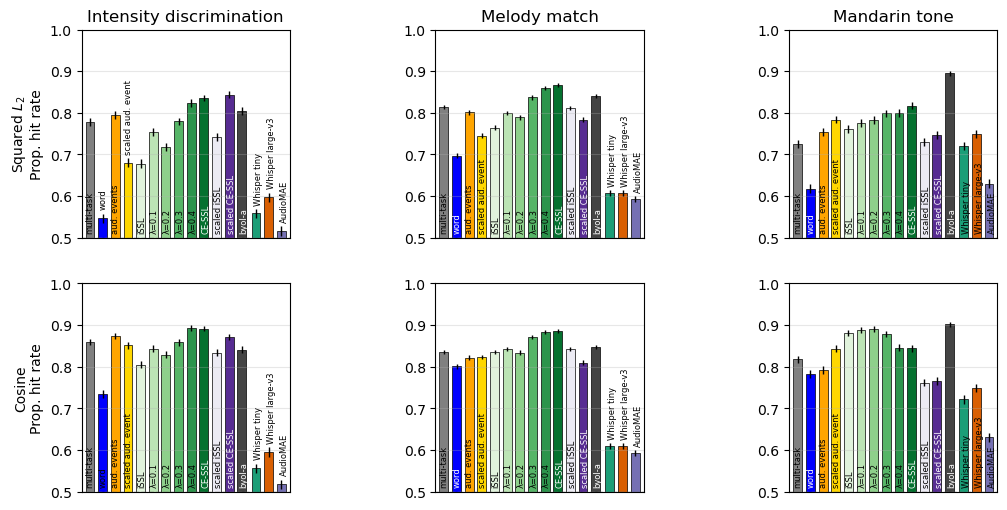

In [56]:

WHISPER_COLORS = {
    "Whisper tiny": "#1b9e77",
    "Whisper large-v3": "#d95f02",
}
AUDIOMAE_BAR_COLOR = "#7570b3"
whisper_models = ["Whisper tiny", "Whisper large-v3"]
audiomae_models = ["AudioMAE"]
# Bar labels: x = bar center. y = just above x-axis if rotated text is shorter than bar (px);
# else a few points above the error bar.
def _coch_byol_models_in_order(results_df):
    # Non-random CochCNN9 + byol-a; order = standard hue order, then any extras.
    standard_order = get_standard_hue_order()
    seen = set()
    for raw in results_df["model_name"].dropna().unique():
        s = str(raw).lower()
        if "random" in s:
            continue
        norm = normalize_model_name(str(raw))
        is_byol = norm == normalize_model_name("byol-a")
        is_coch = norm.startswith("CochCNN9")
        if is_byol or is_coch:
            seen.add(norm)
    ordered = [m for m in standard_order if m in seen]
    extras = sorted(seen - set(ordered))
    return ordered + extras


coch_model_names = _coch_byol_models_in_order(results_df)
coch_plot_df = results_df[
    results_df.model_name.apply(lambda x: normalize_model_name(str(x)) in set(coch_model_names))
].copy()

base_colors = get_standard_base_colors()
hue_dict = build_model_palette(coch_model_names, base_colors)
print(f"Coch/BYOL models in plot ({len(coch_model_names)}): {coch_model_names}")


def _get_whisper_last_layer(model_name, task_df):
    mdf = task_df[task_df.model_name == model_name]
    if mdf.empty:
        return pd.DataFrame()
    block_layers = [l for l in mdf.layer.unique() if l.startswith("encoder_block_")]
    if not block_layers:
        return pd.DataFrame()
    last_block = max(block_layers, key=lambda l: int(l.split("_")[-1]))
    if "ln_post" in mdf.layer.unique():
        last_block = "ln_post"
    return mdf[mdf.layer == last_block].copy()


def _get_audiomae_last_layer(model_name, task_df):
    mdf = task_df[task_df.model_name == model_name]
    if mdf.empty:
        return pd.DataFrame()
    if "norm" in mdf.layer.unique():
        return mdf[mdf.layer == "norm"].copy()
    block_layers = [l for l in mdf.layer.unique() if l.startswith("block_")]
    if not block_layers:
        return pd.DataFrame()
    last_block = max(block_layers, key=lambda l: int(l.split("_")[-1]))
    return mdf[mdf.layer == last_block].copy()


METRIC_ROWS = [
    ("L2", "sqr_l2_judgement", r"Squared $L_2$"),
    ("Cosine", "cos_judgement", "Cosine"),
]

TASK_COLS = [
    ("Loudness order discrimination", "Intensity discrimination"),
    ("Melody match", "Melody match"),
    ("Mandarin tone discrimination", "Mandarin tone"),
]

n_cols = len(TASK_COLS)
n_rows = len(METRIC_ROWS)
n_bars_est = len(coch_model_names) + len(whisper_models) + len(audiomae_models)
fig_w = max(3.2 * n_cols, 0.28 * n_bars_est * n_cols)
fig_h = 3.0 * n_rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))

for row_idx, (metric_key, value_col, metric_label) in enumerate(METRIC_ROWS):
    for col_idx, (task_name, task_label) in enumerate(TASK_COLS):
        ax = axes[row_idx, col_idx]
        ax.set_ylim(0.5, 1.0)

        task_coch = coch_plot_df[(coch_plot_df.layer == "relu4") & (coch_plot_df.task == task_name)]
        task_whisper = whisper_all[whisper_all.task == task_name]
        task_audiomae = audiomae_all[audiomae_all.task == task_name] if not audiomae_all.empty else pd.DataFrame()

        all_models = list(coch_model_names)
        all_colors = dict(hue_dict)
        for wm in whisper_models:
            wdf = _get_whisper_last_layer(wm, task_whisper)
            if not wdf.empty:
                all_models.append(wm)
                all_colors[wm] = WHISPER_COLORS[wm]
        for am in audiomae_models:
            adf = _get_audiomae_last_layer(am, task_audiomae)
            if not adf.empty:
                all_models.append(am)
                all_colors[am] = AUDIOMAE_BAR_COLOR

        pretrained_models = set(whisper_models) | set(audiomae_models)
        x_pos = 0
        bar_width = 0.7

        for m_idx, m_name in enumerate(all_models):
            if m_name in whisper_models:
                mdf = _get_whisper_last_layer(m_name, task_whisper)
            elif m_name in audiomae_models:
                mdf = _get_audiomae_last_layer(m_name, task_audiomae)
            else:
                mdf = task_coch[task_coch.model_name.apply(normalize_model_name) == normalize_model_name(m_name)]

            if mdf.empty or value_col not in mdf.columns:
                continue

            mean_val = mdf[value_col].mean()
            sem_val = mdf[value_col].sem()
            color = all_colors.get(m_name, "#999999")

            prev_is_pretrained = m_idx > 0 and all_models[m_idx - 1] in pretrained_models
            if m_name in pretrained_models and m_idx > 0 and not prev_is_pretrained:
                x_pos += 0.12

            bar = ax.bar(
                x_pos,
                mean_val,
                width=bar_width,
                color=color,
                edgecolor="black",
                linewidth=0.5,
                yerr=sem_val,
                capsize=0,
                error_kw={"linewidth": 1},
            )

            if m_name in pretrained_models:
                lbl = m_name
                white_text_substrs = []
            else:
                lbl = model_label(m_name, use_ssl_names=True).replace("supervised ", "")
                white_text_substrs = ["word", "CE", "byol"]
                if "Loudness" in task_name:
                    white_text_substrs = ["CE", "byol"]

            set_bar_labels(ax, bar, [lbl],
                white_text_substrs=white_text_substrs,
                ymin_bars=0.51,
                no_olap_pad=0.01,
                fontsize=6,
                sem_vals=[sem_val])
               
            x_pos += 1

        if row_idx == 0:
            ax.set_title(task_label)
        ax.set_ylim(0.5, 1.0)
        ax.margins(x=0.02)
        ax.set_xticks([])
        ax.grid(axis="y", alpha=0.3, zorder=-1)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
        if col_idx == 0:
            ax.set_ylabel(f"{metric_label}\nProp. hit rate")

ratio = 1.0
for ax in np.atleast_1d(axes).ravel():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright - xleft) / (ybottom - ytop)) * ratio)

fig.subplots_adjust(wspace=0.06, hspace=0.22)
plt.show()


## L2 only (single row)

Same models and styling as above, **squared \(L_2\)** only. Requires the previous plot cell (definitions for `coch_model_names`, helpers, etc.).

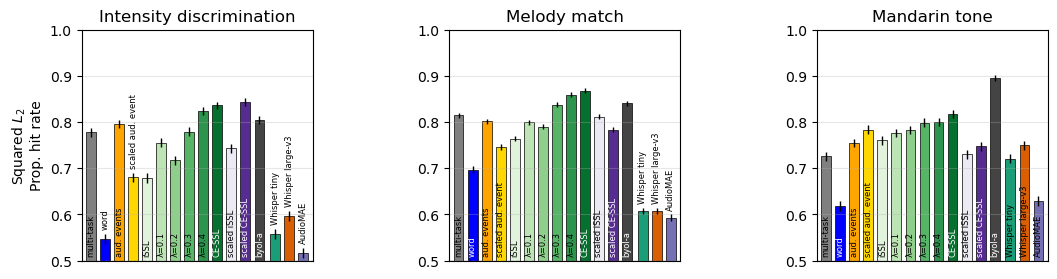

In [ ]:
# Squared L2 only — one row, three task columns (uses setup from the cell above)
value_col = "sqr_l2_judgement"
metric_label = r"Squared $L_2$"
# Uses annotate_bar_label from figure_utils (run import cell).

TASK_COLS = [
    ("Loudness order discrimination", "Intensity discrimination"),
    ("Melody match", "Melody match"),
    ("Mandarin tone discrimination", "Mandarin tone"),
]

n_cols = len(TASK_COLS)
n_bars_est = len(coch_model_names) + len(whisper_models) + len(audiomae_models)
fig_w = max(3.2 * n_cols, 0.28 * n_bars_est * n_cols)
fig_h = 3.0

fig_l2, axes = plt.subplots(1, n_cols, figsize=(fig_w, fig_h))

for col_idx, (task_name, task_label) in enumerate(TASK_COLS):
    ax = axes[col_idx]
    ax.set_ylim(0.5, 1.0)

    task_coch = coch_plot_df[(coch_plot_df.layer == "relu4") & (coch_plot_df.task == task_name)]
    task_whisper = whisper_all[whisper_all.task == task_name]
    task_audiomae = audiomae_all[audiomae_all.task == task_name] if not audiomae_all.empty else pd.DataFrame()

    all_models = list(coch_model_names)
    all_colors = dict(hue_dict)
    for wm in whisper_models:
        wdf = _get_whisper_last_layer(wm, task_whisper)
        if not wdf.empty:
            all_models.append(wm)
            all_colors[wm] = WHISPER_COLORS[wm]
    for am in audiomae_models:
        adf = _get_audiomae_last_layer(am, task_audiomae)
        if not adf.empty:
            all_models.append(am)
            all_colors[am] = AUDIOMAE_BAR_COLOR

    pretrained_models = set(whisper_models) | set(audiomae_models)
    x_pos = 0
    bar_width = 0.7

    for m_idx, m_name in enumerate(all_models):
        if m_name in whisper_models:
            mdf = _get_whisper_last_layer(m_name, task_whisper)
        elif m_name in audiomae_models:
            mdf = _get_audiomae_last_layer(m_name, task_audiomae)
        else:
            mdf = task_coch[task_coch.model_name.apply(normalize_model_name) == normalize_model_name(m_name)]

        if mdf.empty or value_col not in mdf.columns:
            continue

        mean_val = mdf[value_col].mean()
        sem_val = mdf[value_col].sem()
        color = all_colors.get(m_name, "#999999")

        prev_is_pretrained = m_idx > 0 and all_models[m_idx - 1] in pretrained_models
        if m_name in pretrained_models and m_idx > 0 and not prev_is_pretrained:
            x_pos += 0.12

        bar = ax.bar(
            x_pos,
            mean_val,
            width=bar_width,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            yerr=sem_val,
            capsize=0,
            error_kw={"linewidth": 1},
        )

        if m_name in pretrained_models:
            lbl = m_name
            white_text_substrs = []
        else:
            lbl = model_label(m_name, use_ssl_names=True).replace("supervised ", "")
            white_text_substrs = ["word", "CE", "byol", 'Whisper', 'AudioMAE']
            if "Loudness" in task_name:
                white_text_substrs = ["CE", "byol"]

        set_bar_labels(ax, bar, [lbl],
               white_text_substrs=white_text_substrs,
               ymin_bars=0.51,
               no_olap_pad=0.01,
               fontsize=6,
               sem_vals=[sem_val])
               
        x_pos += 1

    ax.set_title(task_label)
    ax.set_ylim(0.5, 1.0)
    ax.margins(x=0.02)
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.3, zorder=-1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    if col_idx == 0:
        ax.set_ylabel(f"{metric_label}\nProp. hit rate")

ratio = 1.0
for ax in np.atleast_1d(axes).ravel():
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright - xleft) / (ybottom - ytop)) * ratio)

# fig_l2.subplots_adjust(wspace=0.06)
plt.show()


## Export figure


In [ ]:

if "fig" not in dir():
    raise RuntimeError("Run the plot cell above first so `fig` is defined.")
out_pdf = fig_out_dir / "zero_shot_all_models_l2_cosine_whisper_audiomae.pdf"
out_png = fig_out_dir / "zero_shot_all_models_l2_cosine_whisper_audiomae.png"
# fig.savefig(out_pdf, bbox_inches="tight")
# fig.savefig(out_png, dpi=200, bbox_inches="tight")
print("Saved:", out_pdf.resolve())
print("Saved:", out_png.resolve())
